In [1]:
%pip install qiskit qiskit_ibm_runtime rustworkx qiskit-aer
%pip install pylatexenc

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -------------------------- ------------- 6.0/9.1 MB 37.0 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 37.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 53.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 112.1 MB/s  0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 74.4 MB/s  0:00:00
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   ---------------------------------------- 540.8/540.8 kB ?  0:00:00

   ----------------------------------------  0/15 [stevedore]
   ----- ----------------------------------  2/15 [rustworkx]
   ---------- -----------------------------  4/15 [pybase64]
   ------------- ------

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, Batch, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QAOAAnsatz
import networkx as nx
import json
from scipy.optimize import minimize
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator

from dwave.system.samplers import DWaveSampler
from dwave.system.composites import EmbeddingComposite
from neal import SimulatedAnnealingSampler
from dimod import Binary, ExactSolver
from dwave.samplers import PathIntegralAnnealingSampler
from tqdm import tqdm

In [2]:
# n_small = 6
# graph = nx.Graph()
# graph.add_nodes_from(np.arange(0, n_small, 1))
# edge_list = [
#     (0, 1),
#     (0, 2),
#     (0, 4),
#     (1, 2),
#     (2, 3),
#     (3, 4),
#     # (5, 2, 1.0),
#     # (5, 3, 1.0),
#     (5, 4),
#     (2, 4),
#     (3, 1),
#     (5, 0),
#     (0, 3)
# ]
# graph.add_edges_from(edge_list)
# nx.draw(graph, with_labels=True)

In [3]:
def build_maxcut_paulis(graph: nx.Graph):
    pauli_list = []
    
    for e in graph.edges():
        pauli_list.append(("ZZ", [e[0], e[1]], 1))
    return pauli_list

def build_maxclique_mis_paulis(graph: nx.Graph, problem_size):
    complement = nx.complement(graph)
    # solve max independent set
    pauli_list = []
    A = 1
    for n in complement.nodes():
        pauli_list.append((("Z"), [n], A))

    B = 2/4
    for e in complement.edges():
        pauli_list.append(("II", [e[0], e[1]], B))
        pauli_list.append(("IZ", [e[0], e[1]], -B))
        pauli_list.append(("ZI", [e[0], e[1]], -B))
        pauli_list.append(("ZZ", [e[0], e[1]], B))
        
    return pauli_list

def build_kclique_paulis(graph, k):
    
    pauli_list = []
    B = 1
    A = B*k + 1
    observable_dict = dict()
    N = graph.number_of_edges()
    M = graph.number_of_edges()

    for n in graph.nodes():
        observable_dict[("Z", (n,))] = observable_dict.get(("Z", (n,)), 0) + A*k - A*0.5*N
        for m in graph.nodes():
            if n >= m:
                continue
            observable_dict[("ZZ", (n,m))] = observable_dict.get(("ZZ", (n,m)), 0) + A*0.5

    for e in graph.edges():
        observable_dict[("Z", (e[1],))] = observable_dict.get(("Z", (e[1],)), 0) + B/4
        observable_dict[("Z", (e[0],))] = observable_dict.get(("Z", (e[0],)), 0) + B/4
        sorted_nm = sorted([e[0], e[1]])
        observable_dict[("ZZ", (sorted_nm[0],sorted_nm[1]))] = observable_dict.get(("ZZ", (sorted_nm[0], sorted_nm[1])), 0) - B/4


    for (pauli, qubits), coeff in observable_dict.items():
        pauli_list.append((pauli, list(qubits), coeff))
    return pauli_list

def build_kclique_paulis_mis(graph, problem_size):
    
    complement = nx.complement(graph)
    pauli_list = []
    k = problem_size["k"]
    B = 1
    A = B*k + 1
    observable_dict = dict()
    N = graph.number_of_nodes()
    M = graph.number_of_edges()

    for n in graph.nodes():
        observable_dict[("Z", (n,))] = observable_dict.get(("Z", (n,)), 0) + A*k - A*0.5*N
        for m in graph.nodes():
            if n >= m:
                continue
            observable_dict[("ZZ", (n,m))] = observable_dict.get(("ZZ", (n,m)), 0) + A*0.5

    for e in complement.edges():
        observable_dict[("Z", (e[1],))] = observable_dict.get(("Z", (e[1],)), 0) - B/4
        observable_dict[("Z", (e[0],))] = observable_dict.get(("Z", (e[0],)), 0) - B/4
        sorted_nm = sorted([e[0], e[1]])
        observable_dict[("ZZ", (sorted_nm[0],sorted_nm[1]))] = observable_dict.get(("ZZ", (sorted_nm[0], sorted_nm[1])), 0) + B/4


    for (pauli, qubits), coeff in observable_dict.items():
        pauli_list.append((pauli, list(qubits), coeff))

    return pauli_list


# paulis = build_kclique_paulis_mis(graph, {"k": 4})
# cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, n_small)
# print(cost_hamiltonian)

In [4]:
# num_layers = 3
# circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=num_layers)
# circuit.measure_all()
# print(circuit)
# print(circuit.parameters)

In [ ]:

# use_simulator = True
# if not use_simulator:
#     service = QiskitRuntimeService(token="zEy7LbjosvnHdbmiUBBWnAPVsm2V-fSKOKka0UgP9JWW", instance="open-instance")

#     backend = service.least_busy(
#         operational=True, simulator=False, min_num_qubits=127
#     )
# else:
#     backend = AerSimulator()
# print(backend)
# pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
# candidate_circuit = pm.run(circuit)
# candidate_circuit.draw("mpl", fold=False, idle_wires=False)

In [8]:

# objective_func_evals = []

# initial_beta = np.pi
# initial_gamma = np.pi / 2
# if use_simulator:
#     initial_params = np.random.rand(2*num_layers)
# else:
#     initial_params = [ 4.009e+00,  3.569e+00,  2.692e+00,  2.168e+00] # paste locally found variables here

# def cost_func_estimator(params, ansatz, hamiltonian, estimator):

#     isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

#     pub = (ansatz, isa_hamiltonian, params)
#     job = estimator.run([pub])

#     result = job.result()[0]
#     cost = result.data.evs
#     objective_func_evals.append(cost)

#     return cost

# # estimator = Estimator(mode=backend)
# estimator = StatevectorEstimator()
# # estimator.options.default_shots = 1000

# # estimator.options.dynamical_decoupling.enable = True
# # estimator.options.dynamical_decoupling.sequence_type = "XY4"
# # estimator.options.twirling.enable_gates = True
# # estimator.options.twirling.num_randomizations = "auto"
# # estimator.options.environment.job_tags = ["TUT_QAOA"]
# if use_simulator:
#     candidate_circuit_no_meas = candidate_circuit.remove_final_measurements(inplace=False)

#     result = minimize(
#         cost_func_estimator,
#         initial_params,
#         args=(candidate_circuit_no_meas, cost_hamiltonian, estimator),
#         method="COBYLA",
#         tol=1e-2
#     )
#     print(result)

#     plt.figure(figsize=(12, 6))
#     plt.plot(objective_func_evals)
#     plt.xlabel("Iteration")
#     plt.ylabel("Cost")
#     plt.show()

In [9]:
# if use_simulator:
#     optimized_circuit = candidate_circuit.assign_parameters(result.x)
# else:
#     optimized_circuit = candidate_circuit.assign_parameters(initial_params)
# optimized_circuit.draw("mpl", fold=False, idle_wires=False)

In [10]:
# # service = QiskitRuntimeService(token="zEy7LbjosvnHdbmiUBBWnAPVsm2V-fSKOKka0UgP9JWW", instance="open-instance")

# # backend = service.least_busy(
# #     operational=True, simulator=False, min_num_qubits=127
# # )

# sampler = Sampler(mode=backend)
# sampler.options.default_shots = 1000

# sampler.options.dynamical_decoupling.enable = True
# sampler.options.dynamical_decoupling.sequence_type = "XY4"
# sampler.options.twirling.enable_gates = True
# sampler.options.twirling.num_randomizations = "auto"

# sampler.options.environment.job_tags = ["TUT_QAOA"]

# pub = (optimized_circuit, )
# job = sampler.run([pub], shots=int(1e4))
# counts_int = job.result()[0].data.meas.get_int_counts()
# counts_bin = job.result()[0].data.meas.get_counts()
# shots = sum(counts_int.values())
# final_distribution_int = {key: val / shots for key, val in counts_int.items()}
# final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
# print(final_distribution_int)

In [11]:
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


# keys = list(final_distribution_int.keys())
# values = list(final_distribution_int.values())
# most_likely = keys[np.argmax(np.abs(values))]
# most_likely_bitstring = to_bitstring(most_likely, len(graph))
# most_likely_bitstring.reverse()

# print("Result bitstring:", most_likely_bitstring)


In [12]:
# plt.rcParams.update({"font.size": 10})
# final_bits = final_distribution_bin
# values = np.abs(list(final_bits.values()))
# top_4_values = sorted(values, reverse=True)[:4]
# positions = []
# for value in top_4_values:
#     positions.append(np.where(values == value)[0])
# fig = plt.figure(figsize=(11, 6))
# ax = fig.add_subplot(1, 1, 1)
# plt.xticks(rotation=90)
# plt.title("Result Distribution")
# plt.xlabel("Bitstrings (reversed)")
# plt.ylabel("Probability")
# ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
# for p in positions:
#     ax.get_children()[int(p[0])].set_color("tab:purple")
# plt.show()

In [13]:
# # auxiliary function to plot graphs
# def plot_result(G, x):
#     colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
#     pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
#     rx.visualization.mpl_draw(
#         G, node_color=colors, node_size=100, alpha=0.8, pos=pos, with_labels=True
#     )
#     cut_size = 0
#     for e in G.edge_list():
#         cut_size = cut_size + (1 if x[e[0]] != x[e[1]] else 0)

#     print(f"Cut size: {cut_size}")

# def plot_maxclique_result(G, x):
#     colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
#     pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
#     rx.visualization.mpl_draw(
#         G, node_color=colors, node_size=100, alpha=0.8, pos=pos, with_labels=True
#     )

#     clique_size = 0
#     for i in x:
#         clique_size += i

#     print(f"Max clique size: {clique_size}")

# plot_maxclique_result(graph, most_likely_bitstring)

In [26]:
def generate_graph_with_k_clique(n, p, k):
    graph = nx.erdos_renyi_graph(n, p)
    clique_nodes = np.arange(n)
    np.random.shuffle(clique_nodes)
    clique_nodes = clique_nodes[:k]
    # print(clique_nodes)
    edges_to_add = []
    for node1 in clique_nodes:
        for node2 in clique_nodes:
            if node1 == node2:
                continue
            if not graph.has_edge(node1, node2) and (node1, node2) not in edges_to_add:
                edges_to_add.append((node1, node2))
    graph.add_edges_from(edges_to_add)
    return graph

In [25]:
def is_clique(graph: nx.Graph, solution):
    solution_npy = np.array(solution)
    mask = solution_npy == 1
    node_indices = np.array(list(graph.nodes()))[mask]
    for n1 in node_indices:
        for n2 in node_indices:
            if n1 == n2:
                continue
            if not graph.has_edge(n1, n2):
                return False
    return True

In [24]:
def validate_max_clique_solutions(graph, solutions, k):
    return validate_k_clique_solutions(graph, solutions, k)

def validate_k_clique_solutions(graph, solutions, k):
    valid_cliques = 0
    k_cliques = 0
    for solution in solutions:
        is_valid = is_clique(graph, solution)
        is_k_clique = sum(solution) == k and is_valid
        valid_cliques += 1 if is_valid else 0
        k_cliques += 1 if is_k_clique else 0
    return {
        "valid_cliques": valid_cliques,
        "k_cliques": k_cliques,
        "found_solution": k_cliques > 0
    }

In [ ]:
def generate_k_clique_instance(size_info):
    return generate_graph_with_k_clique(size_info["n"], size_info["p"], size_info["k"])

def generate_max_clique_instance(size_info):
    return generate_graph_with_k_clique(size_info["n"], size_info["p"], size_info["k"])

BinaryQuadraticModel({'0': -20.0, '1': -20.0, '2': -20.0, '3': -20.0, '4': -20.0}, {('1', '0'): 8.0, ('2', '0'): 9.0, ('2', '1'): 8.0, ('3', '0'): 8.0, ('3', '1'): 9.0, ('3', '2'): 8.0, ('4', '0'): 8.0, ('4', '1'): 8.0, ('4', '2'): 9.0, ('4', '3'): 8.0}, 36.0, 'BINARY')

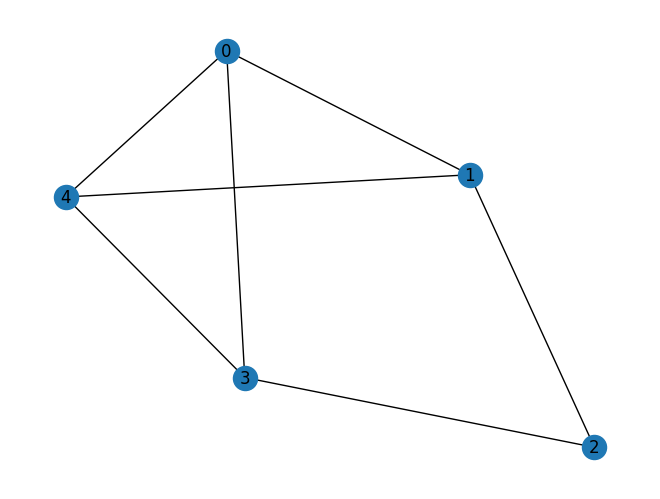

In [93]:
def qa_max_clique_bqm(graph, problem_size):
    x = {i : Binary(i) for i in graph.nodes}
    complement_graph = nx.complement(graph)
    terms = [-x[i] for i in complement_graph.nodes]
    terms += [2*x[i]*x[j] for i,j in complement_graph.edges]
    bqm = sum(terms)
    return bqm

def qa_k_clique_bqm(graph: nx.Graph, problem_size):
    k = problem_size["k"]
    A = k + 1
    B = 1

    x = {i: Binary(str(i)) for i in graph.nodes}
    complement_graph = nx.complement(graph)

    size = sum(x[i] for i in graph.nodes)

    hamiltonian = A * (size - k)**2
    hamiltonian += B * sum(x[i] * x[j] for i, j in complement_graph.edges)

    return hamiltonian

test_graph = nx.erdos_renyi_graph(5, 0.5)
nx.draw(test_graph, with_labels=True)
qa_k_clique_bqm(test_graph, {"k": 3})

In [73]:
# experiments
from tqdm import tqdm

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    result = job.result()[0]
    cost = result.data.evs

    return cost

def test_graph_qa(graph, problem, validate_solutions, iters=10):

    # clique_percent_local = []
    # max_clique_percent_local = []
    solutions = []
    for i in range(iters):
        
        bqm = problem(graph)
        # sampler = SimulatedAnnealingSampler()
        sampler = PathIntegralAnnealingSampler()
        num_reads = 2
        sampleset = sampler.sample(bqm, num_reads=num_reads)
        # energies = np.array([s[1] for s in sampleset.record]) #  if is_clique(graph, s[0]) je do zdej blo vedno true
        # clique_sizes = [sum(r[0]) for r in sampleset.record] #  if is_clique(graph, s[0]) je do zdej blo vedno true
        # successful_runs = energies.shape[0]
        # clique_percent_local.append(successful_runs / num_reads)
        # unique, counts = np.unique(clique_sizes, return_counts=True)
        # exact_sampler = SimulatedAnnealingSampler()
        # exact_sampleset = exact_sampler.sample(bqm, num_reads=50)
        # print(exact_sampleset)
        solution = sampleset.lowest().record[0][0]
        solutions.append(solution)

        # exact_max_clique = sum(solution)
        # max_clique_percent_local.append(np.sum(np.array(clique_sizes) == np.full_like(clique_sizes, exact_max_clique)) / num_reads)
        # print(f"Exact solution: {exact_max_clique}")
        # max_cliques_found.append()
    validation_results = validate_solutions(solutions)
    return validation_results

def test_graph_qaoa(graph, problem, validate_solutions, iters=5, num_layers=3):

    validation_results = []
    estimator = StatevectorEstimator()
    backend = AerSimulator()
    sampler = Sampler(mode=backend)
    sampler.options.default_shots = 1000
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    paulis = problem(graph)
    cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, graph.number_of_nodes())

    circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=num_layers)
    circuit.measure_all()
    candidate_circuit = pm.run(circuit)
    candidate_circuit_no_meas = candidate_circuit.remove_final_measurements(inplace=False)
    found_bitstrings = []
    cumulative_optimized_circuit_depth = 0
    avg_number_evaluations = 0
    optimized_circuits = []
    for i in range(iters):


        initial_params = np.random.rand(2*num_layers) * 2 * np.pi


        result = minimize(
            cost_func_estimator,
            initial_params,
            args=(candidate_circuit_no_meas, cost_hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": 200},
            tol=1e-2
        )
        # print(f"Energy: {cost_func_estimator(result.x, candidate_circuit_no_meas, cost_hamiltonian, estimator)}")
        optimized_circuit = candidate_circuit.assign_parameters(result.x)
        cumulative_optimized_circuit_depth += optimized_circuit.depth()
        avg_number_evaluations += result.nfev
        optimized_circuits.append(optimized_circuit)

    # pub = (optimized_circuit, )
    job = sampler.run(optimized_circuits, shots=1000)
    for res in job.result():
        counts_int = res.data.meas.get_int_counts()

        most_likely = max(counts_int, key=counts_int.get)

        most_likely_bitstring = to_bitstring(most_likely, graph.number_of_nodes())
        most_likely_bitstring.reverse()

        # print("Result bitstring:", most_likely_bitstring)
        found_bitstrings.append(most_likely_bitstring)
    
    
    
    validation_results = validate_solutions(found_bitstrings)
    # print(f"Valid cliques: {valid_cliques}/{iters}")
    # print(f"Valid k-cliques: {k_cliques}/{iters}")

    average_opimized_circuit_depth = cumulative_optimized_circuit_depth / iters
    avg_number_evaluations /= iters
    return validation_results, average_opimized_circuit_depth, avg_number_evaluations


# def test_num_layers(graph, layers, problem, validate_solutions, iters=10):
#     validation_results_per_layer = []
#     average_optimized_circuit_depth_per_layer = []
#     for num in layers:
#         print(f"--- Num layers: {num}")
#         validation_results, optimized_circuit_depth, _ = test_graph(
#             graph, 
#             problem=problem, 
#             validate_solutions=validate_solutions,
#             iters=iters, 
#             num_layers=num)
#         average_optimized_circuit_depth_per_layer.append(optimized_circuit_depth)
#         validation_results_per_layer.append(validation_results)
        
#     return validation_results_per_layer, average_optimized_circuit_depth_per_layer

def test_problem_sizes_qaoa(sizes, generate_instance, instance_count, problem, validate_solutions, layers=4, iters=None):
    validation_results_per_size = []
    depths_per_size = []
    evaluations_per_size = []
    for s in sizes:
        print(f"--- Problem size: {s}")
        graphs = [generate_instance(s) for i in range(instance_count)]
        validation_results_for_graphs = []
        evaluations_per_graph = []
        depths_per_graph = []
        for graph in tqdm(graphs):
            validation_results, optimized_circuit_depth, avg_num_evaluations = test_graph_qaoa(
                graph, 
                problem=lambda x: problem(x, s), 
                validate_solutions=lambda x: validate_solutions(graph, x, s),
                iters=iters if iters != None else s["iters_per_graph"], 
                num_layers=layers if layers != None else s["layers"])
            
            validation_results_for_graphs.append(validation_results)
            evaluations_per_graph.append(avg_num_evaluations)
            depths_per_graph.append(optimized_circuit_depth)
            
        validation_results_per_size.append(validation_results_for_graphs)
        depths_per_size.append(depths_per_graph)
        evaluations_per_size.append(evaluations_per_graph)
        
    return validation_results_per_size, depths_per_size, evaluations_per_size

def test_problem_sizes_qa(sizes, generate_instance, instance_count, problem, validate_solutions, iters=None):
    validation_results_per_size = []
    for s in sizes:
        print(f"--- Problem size: {s}")
        graphs = [generate_instance(s) for i in range(instance_count)]
        validation_results_for_graphs = []
        for graph in tqdm(graphs):
            validation_results = test_graph_qa(
                graph, 
                problem=lambda g: problem(g, s),
                validate_solutions=lambda x: validate_solutions(graph, x, s),
                iters=iters if iters != None else s["iters_per_graph"]
            )
            
            validation_results_for_graphs.append(validation_results)
            
        validation_results_per_size.append(validation_results_for_graphs)
        
    return validation_results_per_size

In [56]:
# k-clique problem size testing
def benchmark_problem_sizes(problem_sizes, output_filename, problem, validate_solutions, num_graphs=3, iters_per_graph=5, method="QAOA"):
    out_dict = dict()
    out_dict["problem_sizes"] = problem_sizes
    out_dict["num_graphs"] = num_graphs
    iters = None
    if not "iters_per_graph" in problem_sizes[0]:
        for i in range(len(problem_sizes)):
            problem_sizes[i]["iters_per_graph"] = iters_per_graph
        out_dict["iters_per_graph"] = iters_per_graph
        iters = iters_per_graph

    if method == "QAOA":


        layers_default = 4
        layers = None
        if not "layers" in problem_sizes[0]:
            for i in range(len(problem_sizes)):
                problem_sizes[i]["layers"] = layers_default
            out_dict["layers"] = layers_default
            layers = layers_default
            
        validation_results, depths_per_size, evaluations_per_size = test_problem_sizes_qaoa(problem_sizes, 
                                                generate_k_clique_instance,
                                                num_graphs, 
                                                problem=problem, 
                                                validate_solutions=validate_solutions,
                                                iters=iters
                                                )
        print(validation_results)
        out_dict["results_per_size"] = validation_results
        out_dict["depths_per_size"] = depths_per_size
        out_dict["evaluations_per_size"] = evaluations_per_size
    
    elif method == "QA":
        validation_results = test_problem_sizes_qa(problem_sizes, 
                                generate_k_clique_instance,
                                num_graphs, 
                                problem=problem, 
                                validate_solutions=validate_solutions,
                                iters=iters
                                )
        out_dict["results_per_size"] = validation_results

    with open("benchmarkResults/" + output_filename, "w") as f:
        json.dump(out_dict, f)
    return out_dict

In [86]:
def er_max_clique_size(n, p):
    return float(np.floor(2*np.log(n)/np.log(1/p)))

In [90]:
# test qa on findinig k-clique
benchmark_graph_size_results = benchmark_problem_sizes(
    [ {"n": n, "p": 0.4, "k": int(er_max_clique_size(n, 0.4))-1, "iters_per_graph" : 50} for n in range(6, 25, 2)],
    "qa_results_kclique_n.json",
    problem=qa_k_clique_bqm,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=60,
    method="QA"
)

--- Problem size: {'n': 6, 'p': 0.4, 'k': 2, 'iters_per_graph': 50}


100%|██████████| 60/60 [00:02<00:00, 23.81it/s]


--- Problem size: {'n': 8, 'p': 0.4, 'k': 3, 'iters_per_graph': 50}


100%|██████████| 60/60 [00:03<00:00, 16.66it/s]


--- Problem size: {'n': 10, 'p': 0.4, 'k': 4, 'iters_per_graph': 50}


...

100%|██████████| 60/60 [00:15<00:00,  3.81it/s]


--- Problem size: {'n': 22, 'p': 0.4, 'k': 5, 'iters_per_graph': 50}


100%|██████████| 60/60 [00:18<00:00,  3.21it/s]


--- Problem size: {'n': 24, 'p': 0.4, 'k': 5, 'iters_per_graph': 50}


100%|██████████| 60/60 [00:22<00:00,  2.72it/s]


In [98]:
# test qa on findinig max-clique
benchmark_graph_size_results = benchmark_problem_sizes(
    [ {"n": n, "p": 0.4, "k": int(er_max_clique_size(n, 0.4)), "iters_per_graph" : 10} for n in range(20, 50, 3)],
    "qa_results_maxclique_n.json",
    problem=qa_max_clique_bqm,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=40,
    method="QA"
)

--- Problem size: {'n': 20, 'p': 0.4, 'k': 6, 'iters_per_graph': 10}


100%|██████████| 40/40 [00:01<00:00, 25.45it/s]


--- Problem size: {'n': 23, 'p': 0.4, 'k': 6, 'iters_per_graph': 10}


100%|██████████| 40/40 [00:02<00:00, 19.98it/s]


--- Problem size: {'n': 26, 'p': 0.4, 'k': 7, 'iters_per_graph': 10}


...

100%|██████████| 40/40 [00:06<00:00,  5.90it/s]


--- Problem size: {'n': 44, 'p': 0.4, 'k': 8, 'iters_per_graph': 10}


100%|██████████| 40/40 [00:07<00:00,  5.22it/s]


--- Problem size: {'n': 47, 'p': 0.4, 'k': 8, 'iters_per_graph': 10}


100%|██████████| 40/40 [00:08<00:00,  4.49it/s]


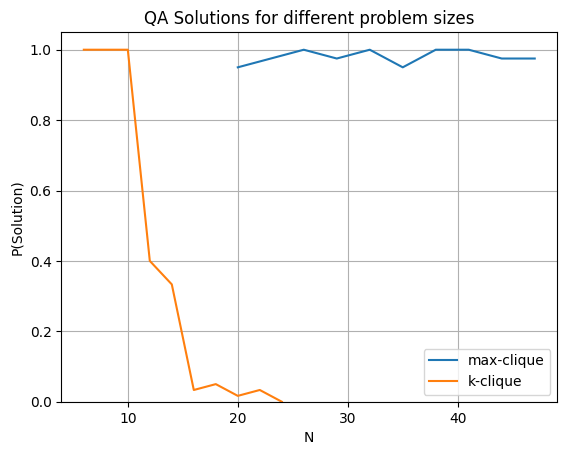

In [102]:
# plot QA success rate vs n
plt.figure()
plt.title("QA Solutions for different problem sizes")
plt.ylabel("P(Solution)")
plt.xlabel("N")

with open("benchmarkResults/qa_results_maxclique_n.json", "r") as f:
    benchmark_results = json.load(f)

found_solutions = [sum([g["found_solution"] for g in s]) for s in benchmark_results["results_per_size"]]
ns = np.array([s["n"] for s in benchmark_results["problem_sizes"]])
plt.plot(ns, np.array(found_solutions) / benchmark_results["num_graphs"], label=f"max-clique")

with open("benchmarkResults/qa_results_kclique_n.json", "r") as f:
    benchmark_results = json.load(f)

found_solutions = [sum([g["found_solution"] for g in s]) for s in benchmark_results["results_per_size"]]
ns = np.array([s["n"] for s in benchmark_results["problem_sizes"]])

plt.plot(ns, np.array(found_solutions) / benchmark_results["num_graphs"], label=f"k-clique")
plt.grid()
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [ ]:
# test different random graph number of nodes
benchmark_graph_size_results = benchmark_problem_sizes(
    [
        {"n": 12, "p": 0.4, "k": 6, "iters_per_graph" : 30, "layers": 2},
        {"n": 12, "p": 0.4, "k": 6, "iters_per_graph" : 30, "layers": 3},
        {"n": 12, "p": 0.4, "k": 6, "iters_per_graph" : 30, "layers": 4},
        {"n": 12, "p": 0.4, "k": 6, "iters_per_graph" : 30, "layers": 5},
    ],
    "results_layers_12.json",
    problem=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=10
)

--- Problem size: {'n': 12, 'p': 0.4, 'k': 6, 'iters_per_graph': 10, 'layers': 2}


100%|██████████| 10/10 [00:21<00:00,  2.14s/it]


--- Problem size: {'n': 12, 'p': 0.4, 'k': 6, 'iters_per_graph': 10, 'layers': 3}


100%|██████████| 10/10 [00:38<00:00,  3.82s/it]


--- Problem size: {'n': 12, 'p': 0.4, 'k': 6, 'iters_per_graph': 10, 'layers': 4}


100%|██████████| 10/10 [00:56<00:00,  5.60s/it]


--- Problem size: {'n': 12, 'p': 0.4, 'k': 6, 'iters_per_graph': 10, 'layers': 5}


100%|██████████| 10/10 [01:21<00:00,  8.20s/it]

[[{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}], [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solutio

{'problem_sizes': [{'n': 8, 'p': 0.4, 'k': 5, 'iters_per_graph': 10, 'layers': 2}, {'n': 8, 'p': 0.4, 'k': 5, 'iters_per_graph': 10, 'layers': 3}, {'n': 8, 'p': 0.4, 'k': 5, 'iters_per_graph': 10, 'layers': 4}, {'n': 8, 'p': 0.4, 'k': 5, 'iters_per_graph': 10, 'layers': 5}], 'num_graphs': 50, 'results_per_size': [[{'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True},

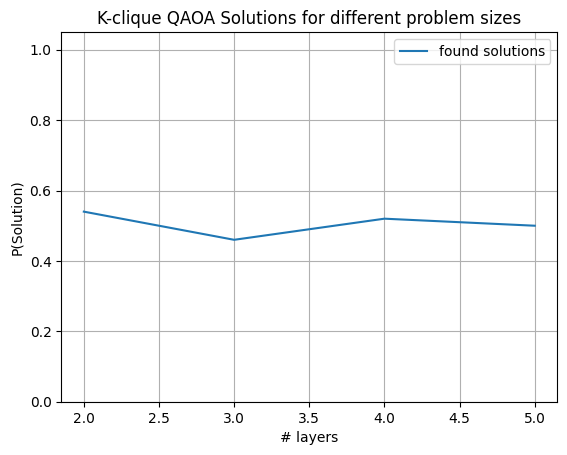

In [42]:
# plot layers vs solution prob
with open("benchmarkResults/results_layers.json", "r") as f:
    benchmark_results = json.load(f)

print(benchmark_results)
# valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
# k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_results["results_per_size"]]
found_solutions = [sum([g["found_solution"] for g in s]) for s in benchmark_results["results_per_size"]]

plt.figure()
plt.title("K-clique QAOA Solutions for different problem sizes")
layers = np.array([s["layers"] for s in benchmark_results["problem_sizes"]])
# plt.xticks(np.arange(num_problem_sizes), benchmark_results["problem_sizes"])
plt.ylabel("P(Solution)")
plt.xlabel("# layers")
# plt.bar(np.arange(num_problem_sizes) - w/3, np.array(valid_cliques_k_clique_sizes) / num_tests_sizes, width=w/3, label="Valid cliques")
# plt.bar(np.arange(num_problem_sizes), np.array(k_cliques_sizes) / num_tests_sizes, width=w/3, label="k-cliques")
# plt.bar(np.arange(num_problem_sizes) + w/3, np.array(found_solutions) / benchmark_results["num_graphs"] , width=w/3, label=f"found solutions")
plt.plot(layers, np.array(found_solutions) / benchmark_results["num_graphs"], label=f"found solutions")
plt.grid()
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [ ]:
# test different random graph number of nodes
benchmark_graph_size_results = benchmark_problem_sizes(
    [
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 5},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 10},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 15},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 20},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 25},
    ],
    "results_graphs_n.json",
    problem=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=15
)

--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 5}


  7%|▋         | 1/15 [00:02<00:39,  2.81s/it]


KeyboardInterrupt: 

In [ ]:
# test different max clique random graph densities
benchmark_problem_sizes(
    [
        {"n": 9, "p": 0.2, "k": 5},
        {"n": 9, "p": 0.4, "k": 5},
        {"n": 9, "p": 0.6, "k": 5},
    ],
    "results_maxclique_graphs_p.json",
    problem=build_maxclique_mis_paulis,
    validate_solutions=lambda g,x,p: validate_max_clique_solutions(g, x, p["k"]),
    num_graphs=5,
    iters_per_graph=8
)

--- Problem size: {'n': 9, 'p': 0.2, 'k': 5}


100%|██████████| 8/8 [00:07<00:00,  1.10it/s]


--- Problem size: {'n': 9, 'p': 0.4, 'k': 5}


100%|██████████| 8/8 [00:04<00:00,  1.76it/s]


--- Problem size: {'n': 9, 'p': 0.6, 'k': 5}


100%|██████████| 8/8 [00:04<00:00,  1.67it/s]

[[{'valid_cliques': 7, 'k_cliques': 6, 'found_solution': True}, {'valid_cliques': 8, 'k_cliques': 7, 'found_solution': True}, {'valid_cliques': 7, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 8, 'k_cliques': 4, 'found_solution': True}], [{'valid_cliques': 8, 'k_cliques': 8, 'found_solution': True}, {'valid_cliques': 8, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}], [{'valid_cliques': 2, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 8, 'k_cliques': 7, 'found_solution': True}, {'valid_cliques': 7, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 4, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 3, 'found_solution': True}]]


{'problem_sizes': [{'n': 9, 'p': 0.2, 'k': 5},
  {'n': 9, 'p': 0.4, 'k': 5},
  {'n': 9, 'p': 0.6, 'k': 5}],
 'num_graphs': 5,
 'iters_per_graph': 8,
 'results_per_size': [[{'valid_cliques': 7,
    'k_cliques': 6,
    'found_solution': True},
   {'valid_cliques': 8, 'k_cliques': 7, 'found_solution': True},
   {'valid_cliques': 7, 'k_cliques': 5, 'found_solution': True},
   {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True},
   {'valid_cliques': 8, 'k_cliques': 4, 'found_solution': True}],
  [{'valid_cliques': 8, 'k_cliques': 8, 'found_solution': True},
   {'valid_cliques': 8, 'k_cliques': 5, 'found_solution': True},
   {'valid_cliques': 5, 'k_cliques': 5, 'found_solution': True},
   {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True},
   {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}],
  [{'valid_cliques': 2, 'k_cliques': 2, 'found_solution': True},
   {'valid_cliques': 8, 'k_cliques': 7, 'found_solution': True},
   {'valid_cliques': 7, 'k_cliques': 0, '

In [ ]:
# test different random graph densities
benchmark_problem_sizes(
    [
        {"n": 6, "p": 0.5, "k": 4},
        {"n": 7, "p": 0.5, "k": 4},
        {"n": 8, "p": 0.5, "k": 5},
        {"n": 9, "p": 0.5, "k": 5},
        {"n": 10, "p": 0.5, "k": 5},
        {"n": 11, "p": 0.5, "k": 5},
        {"n": 12, "p": 0.5, "k": 5},
    ],
    "results_n.json",
    problem=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=12,
    iters_per_graph=12
)

--- Problem size: {'n': 6, 'p': 0.5, 'k': 4}


100%|██████████| 12/12 [00:02<00:00,  4.09it/s]


--- Problem size: {'n': 7, 'p': 0.5, 'k': 4}


100%|██████████| 12/12 [00:02<00:00,  4.18it/s]


--- Problem size: {'n': 8, 'p': 0.5, 'k': 5}


...

100%|██████████| 12/12 [00:04<00:00,  2.40it/s]


--- Problem size: {'n': 12, 'p': 0.5, 'k': 5}


100%|██████████| 12/12 [00:07<00:00,  1.65it/s]

[[{'valid_cliques': 5, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 11, 'k_cliques': 6, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 7, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True}], [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 2, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {

{'problem_sizes': [{'n': 6, 'p': 0.5, 'k': 4},
  {'n': 7, 'p': 0.5, 'k': 4},
  {'n': 8, 'p': 0.5, 'k': 5},
  {'n': 9, 'p': 0.5, 'k': 5},
  {'n': 10, 'p': 0.5, 'k': 5},
  {'n': 11, 'p': 0.5, 'k': 5},
  {'n': 12, 'p': 0.5, 'k': 5}],
 'num_graphs': 12,
 'iters_per_graph': 12,
 'results_per_size': [[{'valid_cliques': 5,
    'k_cliques': 1,
    'found_solution': True},
   {'valid_cliques': 6, 'k_cliques': 4, 'found_solution': True},
   {'valid_cliques': 6, 'k_cliques': 5, 'found_solution': True},
   {'valid_cliques': 6, 'k_cliques': 5, 'found_solution': True},
   {'valid_cliques': 4, 'k_cliques': 2, 'found_solution': True},
   {'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True},
   {'valid_cliques': 4, 'k_cliques': 1, 'found_solution': True},
   {'valid_cliques': 11, 'k_cliques': 6, 'found_solution': True},
   {'valid_cliques': 3, 'k_cliques': 2, 'found_solution': True},
   {'valid_cliques': 5, 'k_cliques': 4, 'found_solution': True},
   {'valid_cliques': 7, 'k_cliques': 5, 'found_

In [ ]:
# test iters per graph
benchmark_graph_size_results = benchmark_problem_sizes(
    [
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 5},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 10},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 18},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 28},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 40},
        {"n": 8, "p": 0.4, "k": 4, "iters_per_graph" : 54},
    ],
    "results_iters_temp.json",
    problem=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=30
)

--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 5}


100%|██████████| 30/30 [00:37<00:00,  1.26s/it]


--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 10}


100%|██████████| 30/30 [01:12<00:00,  2.40s/it]


--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 18}


...

--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 40}


100%|██████████| 30/30 [04:57<00:00,  9.92s/it]


--- Problem size: {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 54}


100%|██████████| 30/30 [06:58<00:00, 13.93s/it]

[[{'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': F

{'problem_sizes': [{'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 5}, {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 10}, {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 18}, {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 28}, {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 40}, {'n': 8, 'p': 0.4, 'k': 4, 'iters_per_graph': 54}], 'num_graphs': 30, 'results_per_size': [[{'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 2, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, {'vali

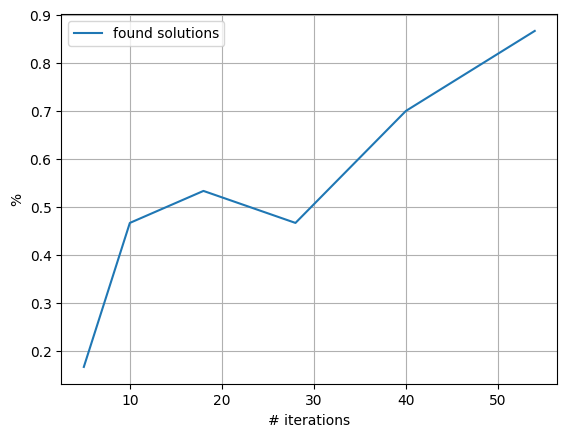

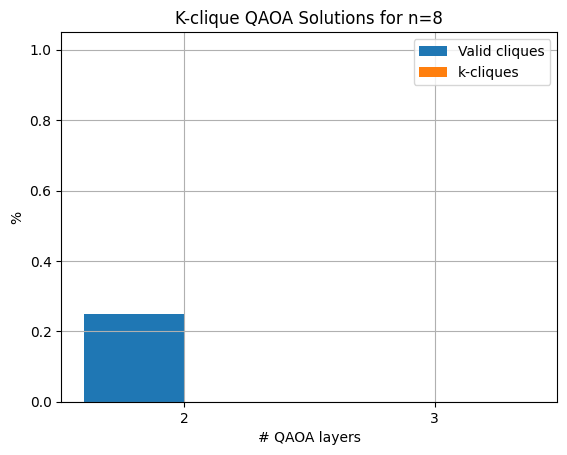

In [518]:
plt.figure()
plt.title("K-clique QAOA Solutions for n=8")
w = 0.4
num_tests = k_clique_layers_results["num_graphs"] * k_clique_layers_results["iters_per_graph"]
num_layers = len(k_clique_layers_results["results_per_layer"])
plt.xticks(np.arange(num_layers), list(k_clique_layers_results["results_per_layer"].keys()))
plt.ylabel("%")
plt.bar(np.arange(num_layers) - w/2, np.array(valid_cliques_k_clique) / num_tests, width=w, label="Valid cliques")
plt.bar(np.arange(num_layers) + w/2, np.array(k_cliques) / num_tests, width=w, label="k-cliques")
# plt.bar(np.arange(len(num_layers)) + w/3, np.array(found_solutions) / num_graphs, width=w/3, label="found solutions")
plt.ylim(0, 1.05)
plt.xlabel("# QAOA layers")
plt.grid()
plt.legend()
plt.show()

NameError: name 'json' is not defined

{'problem_sizes': [{'n': 6, 'p': 0.5, 'k': 4}, {'n': 9, 'p': 0.5, 'k': 5}, {'n': 12, 'p': 0.5, 'k': 5}], 'num_graphs': 15, 'iters_per_graph': 15, 'results_per_size': [[{'valid_cliques': 8, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 11, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 5, 'k_cliques': 4, 'found_solution': True}, {'valid_cliques': 8, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 5, 'k_cliques': 3, 'found_solution': True}, {'valid_cliques': 4, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 2, 'k_cliques': 2, 'found_solution': True}, {'valid_cliques': 7, 'k_cliques': 5, 'found_solution': True}, {'valid_cliques': 6, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 3, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 9, 'k_

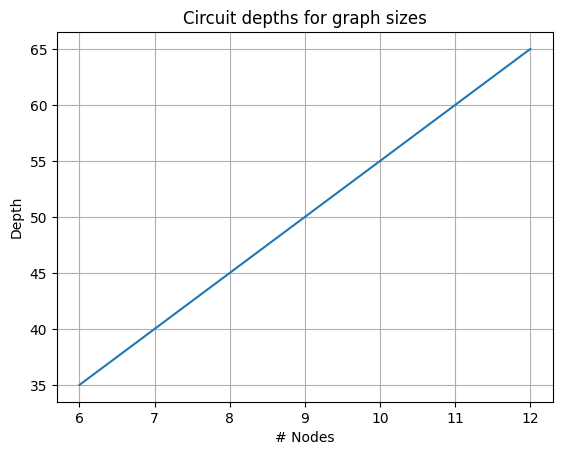

In [57]:
# plot circuit depths
with open("benchmarkResults/results_graphs_p.json", "r") as f:
    benchmark_results = json.load(f)
print(benchmark_results)
depths = [sum(s) / benchmark_results["num_graphs"] for s in benchmark_results["depths_per_size"]]
plt.figure()
plt.title("Circuit depths for graph sizes")
graph_sizes = [s["n"] for s in benchmark_results["problem_sizes"]]
# plt.xticks(np.arange(num_problem_sizes), [s["n"] for s in benchmark_graph_size_results["problem_sizes"]])
plt.ylabel("Depth")
plt.xlabel("# Nodes")
print(graph_sizes, depths)
plt.plot(graph_sizes, depths)
plt.grid()
# plt.legend()
plt.show()

In [461]:
import dill
dill.dump_session('notebook_env.db')

# Grover

{(0, 1): 0, (0, 2): 1, (1, 2): 2}
Transpiled depth: 238


C:\Users\Alen Leban\AppData\Local\Temp\ipykernel_15180\370356545.py:55: DeprecationWarning: ``qiskit.circuit.quantumcircuit.QuantumCircuit.mcx()``'s argument ``mode`` is deprecated as of Qiskit 2.1. It will be removed no earlier than 3 months after the release date. Instead, add a generic MCXGate to the circuit and specify the synthesis method via the ``hls_config`` in the transpilation. Alternatively, specific decompositions are available at https://qisk.it/mcx.
  qc.mcx(q_edge_ancilla, q_isclique, ancilla_qubits=q_mcx_ancilla, mode="v-chain")


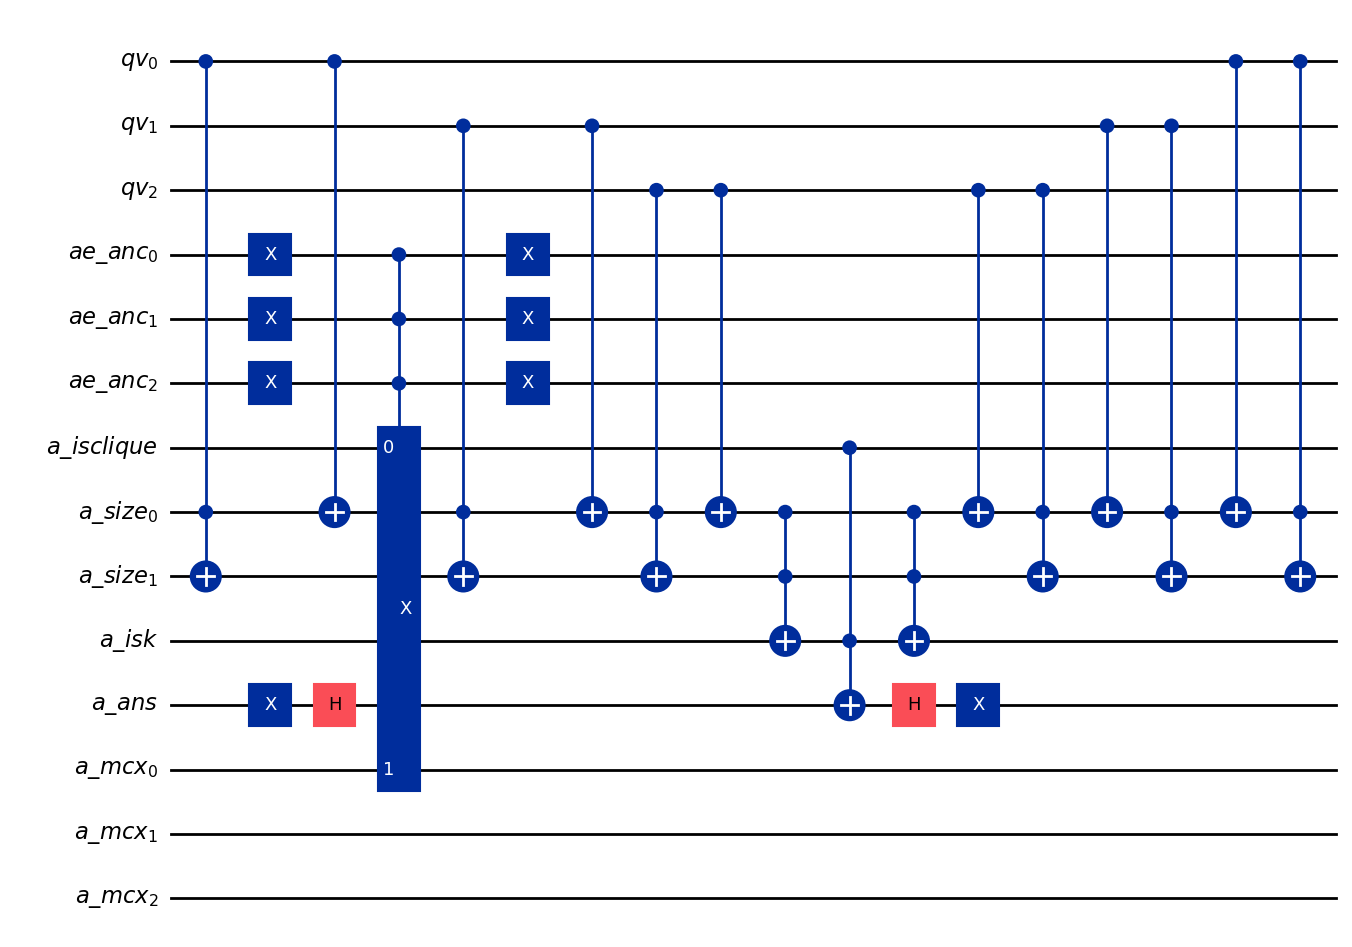

In [8]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister, transpile
from qiskit.circuit.library import grover_operator
from qiskit_ibm_runtime.fake_provider import FakeBrisbane


def is_k_clique_oracle(graph, k):
    n = graph.number_of_nodes()
    q_verts = QuantumRegister(n, "qv")
    # q_edges = QuantumRegister(int(n*n - (1 + n)/2 * n), "qe")
    q_size = AncillaRegister(int(np.ceil(np.log2(n+1))), "a_size")
    q_edge_ancilla = AncillaRegister(int(n*n - (1 + n)/2 * n), "ae_anc")
    q_isclique = AncillaRegister(1, "a_isclique")
    q_isk = AncillaRegister(1, "a_isk")
    q_ans = AncillaRegister(1, "a_ans")
    q_mcx_ancilla = AncillaRegister(len(q_edge_ancilla), "a_mcx")
    qc = QuantumCircuit(q_verts, q_edge_ancilla, q_isclique, q_size, q_isk, q_ans, q_mcx_ancilla)
    pair_to_edge_offset = dict()
    for i in range(n):
        for j in range(n):
            if i>=j:
                continue
            pair_to_edge_offset[(i,j)] = len(pair_to_edge_offset)

    print(pair_to_edge_offset)

    # encoding graph edges
    # for edge in graph.edges():
    #     n1 = edge[0] if edge[0] < edge[1] else edge[1]
    #     n2 = edge[1] if n1 == edge[0] else edge[0]
    #     edge_qubit = q_edges[pair_to_edge_offset[(n1, n2)]]
    #     qc.x(edge_qubit)

    # checking connectivity between candidate vertices
    for n1 in graph.nodes():
        for n2 in graph.nodes():
            if n1 >= n2:
                continue
            has_edge = graph.has_edge(n1, n2)
            if has_edge:
                continue
            ancilla_qubit = q_edge_ancilla[pair_to_edge_offset[(n1, n2)]]
            qc.mcx([n1, n2], ancilla_qubit)

    # count vertices
    for v in range(n):
        for i in reversed(range(1, len(q_size))):
            qc.mcx([q_verts[v]] + list(q_size[:i]), q_size[i])
        qc.cx(q_verts[v], q_size[0])

    # check if vertex count is k
    qc.mcx(q_size, q_isk, ctrl_state=format(k, f'0{len(q_size)}b'))

    # check clique violations
    qc.x(q_edge_ancilla)
    qc.mcx(q_edge_ancilla, q_isclique, ancilla_qubits=q_mcx_ancilla, mode="v-chain")

    qc.x(q_ans)
    qc.h(q_ans)
    qc.mcx([q_isclique, q_isk], q_ans)
    qc.h(q_ans)
    qc.x(q_ans)

    # uncompute

    # qc.mcx(q_edge_ancilla, q_isclique)
    
    qc.x(q_edge_ancilla)
    qc.mcx(q_size, q_isk, ctrl_state=format(k, f'0{len(q_size)}b'))

    for v in reversed(range(n)):
        qc.cx(q_verts[v], q_size[0])
        for i in range(1, len(q_size)):
            qc.mcx([q_verts[v]] + list(q_size[:i]), q_size[i])

    for n1 in reversed(list(graph.nodes())):
        for n2 in reversed(list(graph.nodes())):
            if n1 >= n2:
                continue
            has_edge = graph.has_edge(n1, n2)
            if has_edge:
                continue
            ancilla_qubit = q_edge_ancilla[pair_to_edge_offset[(n1, n2)]]
            qc.mcx([n1, n2], ancilla_qubit)

    # for edge in graph.edges():
    #     n1 = edge[0] if edge[0] < edge[1] else edge[1]
    #     n2 = edge[1] if n1 == edge[0] else edge[0]
    #     edge_qubit = q_edges[pair_to_edge_offset[(n1, n2)]]
    #     qc.x(edge_qubit)

    return qc

test_graph = nx.Graph()
test_graph.add_nodes_from([0, 1, 2])
test_graph.add_edges_from([(0, 1), (0, 2), (1, 2)])

circuit = is_k_clique_oracle(test_graph, 3)

grover_circuit_iter = grover_operator(circuit, reflection_qubits=list(range(4)))
# grover_circuit_iter.draw("mpl")

iterations = 2
grover_circuit = QuantumCircuit(grover_circuit_iter.num_qubits, test_graph.number_of_nodes())
grover_circuit.h(range(test_graph.number_of_nodes()))
grover_circuit.compose(grover_circuit_iter.power(iterations), inplace=True)
grover_circuit.measure(range(test_graph.number_of_nodes()), range(test_graph.number_of_nodes()))
# grover_circuit.draw("mpl")

grover_circuit_t = transpile(grover_circuit, basis_gates=["rz", "sx", "cx"])
print(f"Transpiled depth: {grover_circuit_t.depth()}")
circuit.draw("mpl", scale=1, fold=50)
# print(grover_circuit.num_qubits)

In [9]:
grover_use_simulator = True
if not grover_use_simulator:
    service = QiskitRuntimeService()

    backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=127
    )
else:
    # backend = FakeBrisbane()
    backend = AerSimulator()
print(backend)

# candidate_circuit.draw("mpl")

AerSimulator('aer_simulator')


In [10]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 512
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
pm = generate_preset_pass_manager(optimization_level=2, backend=backend)
candidate_circuit = pm.run(grover_circuit)

print("Original qubits:", grover_circuit.num_qubits)
print("Transpiled qubits:", candidate_circuit.num_qubits)
print("Backend qubits:", backend.num_qubits)

print("depth:", candidate_circuit.depth())
print("ops:", candidate_circuit.count_ops())
print("qubits:", candidate_circuit.num_qubits)

Original qubits: 14
Transpiled qubits: 14
Backend qubits: 30
depth: 38
ops: OrderedDict({'cx': 22, 'ccx': 20, 'u2': 20, 'x': 5, 'h': 3, 'tdg': 3, 't': 3, 'u3': 3, 'measure': 3, 'mcx': 2, 'u1': 1})
qubits: 14


BitArray(<shape=(), num_shots=512, num_bits=3>)
{7: 0.654296875, 0: 0.04296875, 5: 0.052734375, 1: 0.060546875, 4: 0.064453125, 6: 0.041015625, 3: 0.041015625, 2: 0.04296875}
{7: 335, 0: 22, 5: 27, 1: 31, 4: 33, 6: 21, 3: 21, 2: 22}
{'111': 335, '000': 22, '101': 27, '001': 31, '100': 33, '110': 21, '011': 21, '010': 22}


c:\Users\Alen Leban\Documents\magisterij\magistrska\KvantneKlike\.venv\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:271: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


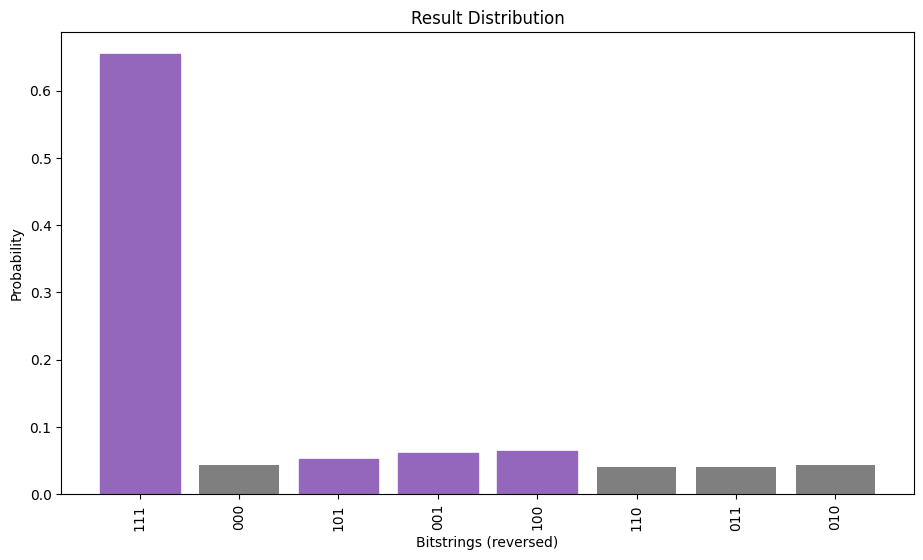

In [11]:
pub = (candidate_circuit, )
job = sampler.run([pub])
print(job.result()[0].data.c)
counts_int = job.result()[0].data.c.get_int_counts()
counts_bin = job.result()[0].data.c.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)
print(counts_int)
print(counts_bin)
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=90)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

161


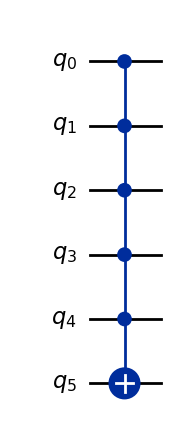

In [12]:
c = QuantumCircuit(6)
c.mcx(list(range(c.num_qubits-1)), c.num_qubits-1)
ct = transpile(c, basis_gates=["rz", "sx", "cx"])
print(ct.depth())
c.draw("mpl")

[<Qubit register=(6, "q34"), index=0>, <Qubit register=(6, "q34"), index=1>, <Qubit register=(6, "q34"), index=2>, <Qubit register=(6, "q34"), index=3>, <Qubit register=(6, "q34"), index=4>]
62


C:\Users\Alen\AppData\Local\Temp\ipykernel_8800\278481401.py:6: DeprecationWarning: ``qiskit.circuit.quantumcircuit.QuantumCircuit.mcx()``'s argument ``mode`` is deprecated as of Qiskit 2.1. It will be removed no earlier than 3 months after the release date. Instead, add a generic MCXGate to the circuit and specify the synthesis method via the ``hls_config`` in the transpilation. Alternatively, specific decompositions are available at https://qisk.it/mcx.
  c.mcx(c.qubits[:-c.num_ancillas-1], c.qubits[-c.num_ancillas-1], mode="v-chain", ancilla_qubits=c.ancillas)


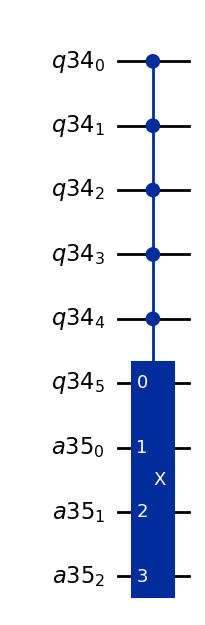

In [ ]:
from qiskit.circuit.library import MCXVChain

c = QuantumCircuit(QuantumRegister(6), AncillaRegister(3))
print(c.qubits[:-c.num_ancillas-1])

c.mcx(c.qubits[:-c.num_ancillas-1], c.qubits[-c.num_ancillas-1], mode="v-chain", ancilla_qubits=c.ancillas)
ct = transpile(c, basis_gates=["rz", "sx", "cx"])
print(ct.depth())
c.draw("mpl")